In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import shap
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('/content/drive/MyDrive/customer_purchase_data.csv') # Replace with actual filename
print(df.head())
print(df.info())
print(df.isnull().sum())


   Age  Gender   AnnualIncome  NumberOfPurchases  ProductCategory  \
0   40       1   66120.267939                  8                0   
1   20       1   23579.773583                  4                2   
2   27       1  127821.306432                 11                2   
3   24       1  137798.623120                 19                3   
4   31       1   99300.964220                 19                1   

   TimeSpentOnWebsite  LoyaltyProgram  DiscountsAvailed  PurchaseStatus  
0           30.568601               0                 5               1  
1           38.240097               0                 5               0  
2           31.633212               1                 0               1  
3           46.167059               0                 4               1  
4           19.823592               0                 0               1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null C

In [5]:
df.fillna(df.mean(), inplace=True)

# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

# Define features and target
X = df.drop('PurchaseStatus', axis=1)  # Replace 'Purchased' with actual target column
y = df['PurchaseStatus']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
model = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}
grid = GridSearchCV(model, param_grid, cv=5, scoring='f1')
grid.fit(X_train, y_train)
best_model = grid.best_estimator_


              precision    recall  f1-score   support

           0       0.92      0.97      0.95       172
           1       0.96      0.89      0.92       128

    accuracy                           0.94       300
   macro avg       0.94      0.93      0.93       300
weighted avg       0.94      0.94      0.94       300



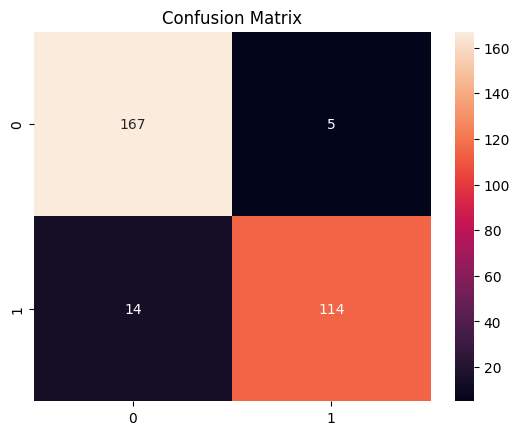

In [8]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()


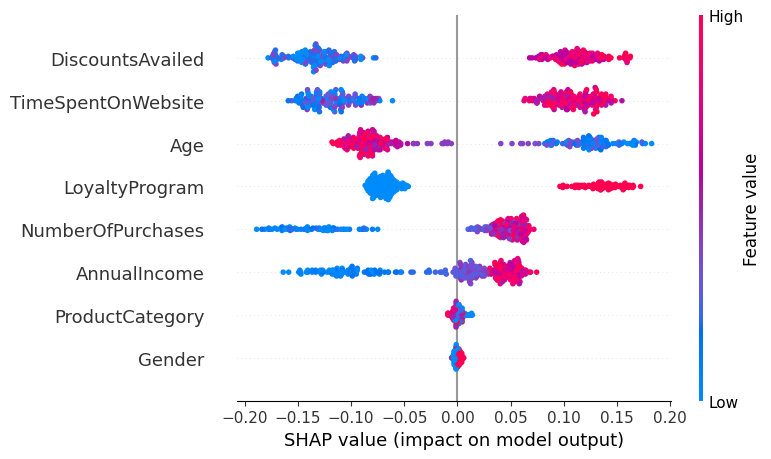

In [10]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Global importance for class 1
shap.summary_plot(shap_values[:, :, 1], X_test)

# Local explanation for the first prediction (index 0) of class 1
shap.force_plot(explainer.expected_value[1], shap_values[0, :, 1], X_test.iloc[0])